In [626]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from numpy.lib.stride_tricks import sliding_window_view

# Load signal
mat_path = '/Users/alicewesterberg/Desktop/wirelessproject/eitn21/Signals_task3/signal3.mat'
data = scipy.io.loadmat(mat_path)
r = data['R'].flatten()

# System parameters
fs = 44100
fc = 10000
Nsc = 128
Ncp = 20
Tsym = 58 * 10**-3


**Demodulation**

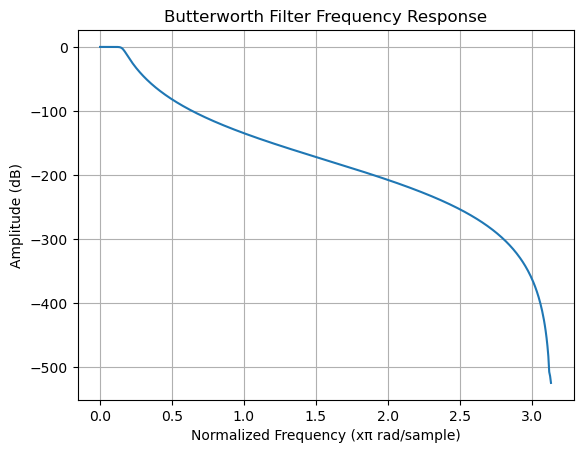

In [627]:
n = np.arange(len(r))
r_I =  2 * r * np.cos(2 * np.pi * fc * n / fs)
r_Q = -2 * r * np.sin(2 * np.pi * fc * n / fs)
from scipy.signal import butter, freqz, filtfilt

b, a = butter(8, 0.05)
r_I_filt = filtfilt(b, a, r_I)
r_Q_filt = filtfilt(b, a, r_Q)

w, h = freqz(b, a)
plt.plot(w, 20 * np.log10(abs(h)))
plt.title('Butterworth Filter Frequency Response')
plt.xlabel('Normalized Frequency (xπ rad/sample)')
plt.ylabel('Amplitude (dB)')
plt.grid()
plt.show()

It shows how the filter attenuates different frequencies, with the x-axis representing the normalized frequency and the y-axis representing the amplitude in decibels (dB). The plot helps to visualize the characteristics of the Butterworth filter, such as its cutoff frequency and roll-off rate. High frequency components are attenuated, while low frequency components are preserved, which is characteristic of a low-pass filter. The cutoff frequency is around 0.05 times the Nyquist frequency, which corresponds to the normalized cutoff frequency used in the Butterworth filter design.

**A/D Conversion and Down Sampling**

In [628]:
D = fs * Tsym / Nsc   # exact ratio, not rounded
idx = np.arange(0, len(r_I_filt), D)
r_I_down = np.interp(idx, np.arange(len(r_I_filt)), r_I_filt)
r_Q_down = np.interp(idx, np.arange(len(r_Q_filt)), r_Q_filt)
r_bb = r_I_down + 1j * r_Q_down
print(f'D={D:.4f}, r_bb length={len(r_bb)}, ~{len(r_bb)//(Nsc+Ncp)} OFDM symbols')

D=19.9828, r_bb length=6359, ~42 OFDM symbols


**Synchronization and Removal of the Cyclic Prefix**

In [629]:
Tper = Nsc // 2  # = 64, pilot symbol period

wins  = sliding_window_view(r_bb, 2 * Tper)
gamma = np.sum(wins[:, :Tper] * np.conj(wins[:, Tper:]), axis=1)
phi1  = np.sum(np.abs(wins[:, :Tper])**2, axis=1)
phi2  = np.sum(np.abs(wins[:, Tper:])**2, axis=1)
mu    = np.abs(gamma) / np.sqrt(phi1 * phi2 + 1e-10)

T0 = np.argmax(mu)          # argmax falls at start of pilot data (after CP)
t0 = T0 - Ncp - 1           # start of pilot CP; -1 corrects a sub-sample sync bias
print(f'Pilot starts at: {t0}, OFDM data at: {T0}')

Nofdm   = Nsc + Ncp
n_sym   = (len(r_bb) - t0) // Nofdm
ofdm_blocks = r_bb[t0 : t0 + n_sym*Nofdm].reshape(n_sym, Nofdm)
ofdm_data   = ofdm_blocks[:, Ncp:]
print(f'Total OFDM symbols: {n_sym}')

Pilot starts at: 4002, OFDM data at: 4023
Total OFDM symbols: 15


**FFT**

In [630]:
X = np.fft.fft(ofdm_data, axis=1)

**Channel estimation**

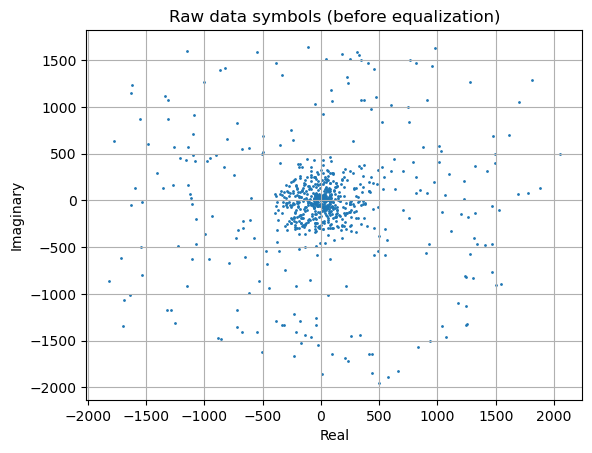

In [631]:
from scipy.signal import savgol_filter

# H from zero-padded subcarriers 15-127 of the length OFDM symbol (X[1])
# Those subcarriers carry all-zero bits → QPSK symbol = 1+j
H_from_len = X[1, 15:] / (1+1j)   # shape (113,)
len_pos = np.arange(15, 128)

# Interpolate real and imaginary parts separately to all 128 subcarriers
# (more stable than interpolating magnitude and phase)
all_pos = np.arange(Nsc)
H_init = (np.interp(all_pos, len_pos, H_from_len.real)
        + 1j * np.interp(all_pos, len_pos, H_from_len.imag))

# Use ALL 64 even subcarriers from the pilot symbol to improve H estimate
# Pilot: X[0, 2k] = 2 * P[k] * H[2k], where P[k] ∈ {+1, -1}
even_idx = np.arange(0, Nsc, 2)
raw = X[0, even_idx]                       # received pilot at even subcarriers
ratio = raw / (2 * H_init[even_idx])
P = np.where(np.abs(ratio.real) >= np.abs(ratio.imag),
             np.sign(ratio.real), np.sign(ratio.imag))
P = np.where(P == 0, 1.0, P)
H_from_pilot = raw / (2 * P)              # H estimate at all 64 even subcarriers

# Combine estimates: average where both are available (even sc >= 15)
known_set = set(len_pos.tolist())
H_full = np.empty(Nsc, dtype=complex)
for k in range(Nsc):
    in_len = k in known_set
    in_pil = (k % 2 == 0)
    if in_len and in_pil:
        H_full[k] = 0.5 * (H_from_len[k - 15] + H_from_pilot[k // 2])
    elif in_len:
        H_full[k] = H_from_len[k - 15]
    elif in_pil:
        H_full[k] = H_from_pilot[k // 2]
    else:
        H_full[k] = 0  # odd subcarrier below 15 — filled next

# Fill odd subcarriers 1,3,...,13 by averaging their even neighbours
for k in range(1, 15, 2):
    H_full[k] = 0.5 * (H_full[k - 1] + H_full[k + 1])

# Smooth both parts to reduce per-subcarrier noise
H_full = savgol_filter(H_full.real, 7, 3) + 1j * savgol_filter(H_full.imag, 7, 3)

plt.scatter(X[2:8].real.flatten(), X[2:8].imag.flatten(), s=1)
plt.title('Raw data symbols (before equalization)'); plt.xlabel('Real'); plt.ylabel('Imaginary')
plt.grid(); plt.show()

**Remove pilots**

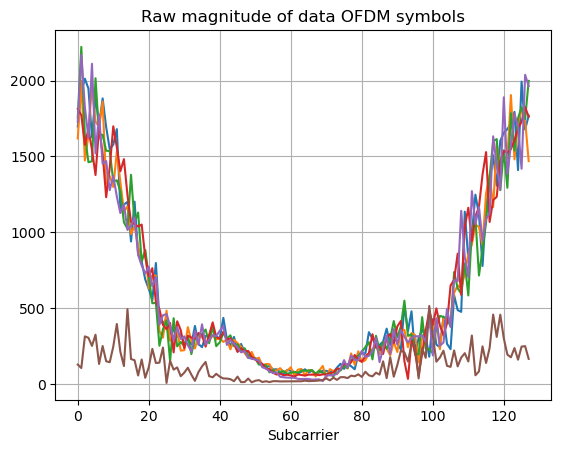

In [632]:
X_data = X[1:]   # length symbol + all remaining symbols
plt.plot(np.abs(X[2:8]).T)
plt.title('Raw magnitude of data OFDM symbols'); plt.xlabel('Subcarrier'); plt.grid(); plt.show()

**Equalization**

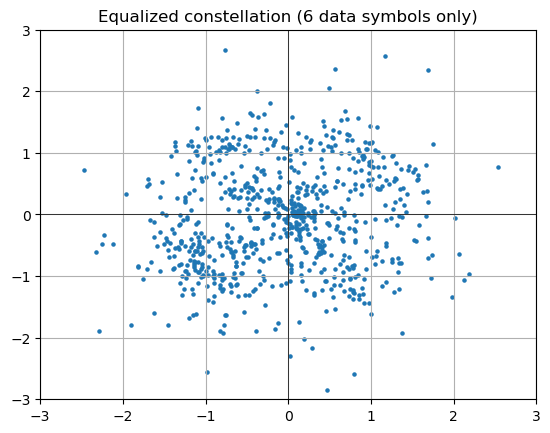

In [633]:
X_eq = X_data / H_full   # equalize: divide each row by H estimate

# Plot only the 6 actual data symbols (X_eq[0]=length, X_eq[1:7]=data)
plt.scatter(X_eq[1:7].real.flatten(), X_eq[1:7].imag.flatten(), s=5)
plt.xlim(-3, 3); plt.ylim(-3, 3)
plt.axhline(0, color='k', lw=0.5); plt.axvline(0, color='k', lw=0.5)
plt.title('Equalized constellation (6 data symbols only)')
plt.grid(); plt.show()

In [634]:

bits = []
for sym in X_eq.flatten():
    bits.append('1' if sym.real < 0 else '0')
    bits.append('1' if sym.imag < 0 else '0')


**QPSK DEMOD**

In [635]:
bits = []
for sym in X_eq.flatten():
    bits.append('1' if sym.real < 0 else '0')
    bits.append('1' if sym.imag < 0 else '0')

**Decoding and ASCII**

In [ ]:
from commpy.channelcoding import Trellis, viterbi_decode

bits_arr  = np.array(bits).astype(int)
bits_len  = bits_arr[:256].astype(float)
bits_data = bits_arr[256:].astype(float)

best_msg, best_score, best_l_m = None, -1, None

for g2 in (0o45, 0o51):
    trellis = Trellis(memory=np.array([5]), g_matrix=np.array([[0o77, g2]]))

    # Decode the message length from the length OFDM symbol
    decoded_len = viterbi_decode(bits_len, trellis, decoding_type='hard')
    l_m_auto = int(''.join(decoded_len[:10].astype(int).astype(str)), 2)
    print(f'g2=0o{g2:o}: auto-detected length = {l_m_auto}')
    
    # Search around the decoded length in case of length-symbol decode errors
    for l_m in set([l_m_auto] + list(range(max(1, l_m_auto - 20), l_m_auto + 21))):
        if l_m < 1 or l_m > 400:
            continue
        needed = 14 * l_m + 10
        if needed > len(bits_data):
            continue
        # Use tb_depth=35 (larger than default 25) for more reliable traceback
        decoded_msg = viterbi_decode(bits_data[:needed], trellis, tb_depth=35, decoding_type='hard')
        msg_bits = decoded_msg[:l_m * 7].astype(int).astype(str)
        message = ''.join(
            chr(int(''.join(msg_bits[i:i+7]), 2))
            for i in range(0, l_m * 7, 7)
            if len(msg_bits[i:i+7]) == 7
        )
        score = sum(c.isalpha() or c == ' ' for c in message) / max(1, len(message))
        if score > best_score:
            best_score, best_msg, best_l_m = score, message, l_m

print(f'\nBest decode (length={best_l_m}, score={best_score:.3f}):')
print(best_msg)
          

g2=0o45: auto-detected length = 104
